## ALL MODULES & LIBRARIES IMPORTS

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec



## S&P 500 from 2006 to 2012

In [107]:
sp500 = yf.download("^GSPC", start="2006-01-01", end="2012-12-31")
sp500 = sp500[['Close']]
print(sp500.head(50))

[*********************100%***********************]  1 of 1 completed

Price             Close
Ticker            ^GSPC
Date                   
2006-01-03  1268.800049
2006-01-04  1273.459961
2006-01-05  1273.479980
2006-01-06  1285.449951
2006-01-09  1290.150024
2006-01-10  1289.689941
2006-01-11  1294.180054
2006-01-12  1286.060059
2006-01-13  1287.609985
2006-01-17  1282.930054
2006-01-18  1277.930054
2006-01-19  1285.040039
2006-01-20  1261.489990
2006-01-23  1263.819946
2006-01-24  1266.859985
2006-01-25  1264.680054
2006-01-26  1273.829956
2006-01-27  1283.719971
2006-01-30  1285.189941
2006-01-31  1280.079956
2006-02-01  1282.459961
2006-02-02  1270.839966
2006-02-03  1264.030029
2006-02-06  1265.020020
2006-02-07  1254.780029
2006-02-08  1265.650024
2006-02-09  1263.780029
2006-02-10  1266.989990
2006-02-13  1262.859985
2006-02-14  1275.530029
2006-02-15  1280.000000
2006-02-16  1289.380005
2006-02-17  1287.239990
2006-02-21  1283.030029
2006-02-22  1292.670044
2006-02-23  1287.790039
2006-02-24  1289.430054
2006-02-27  1294.119995
2006-02-28  1280

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/text.py:898: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/text.py:757: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))


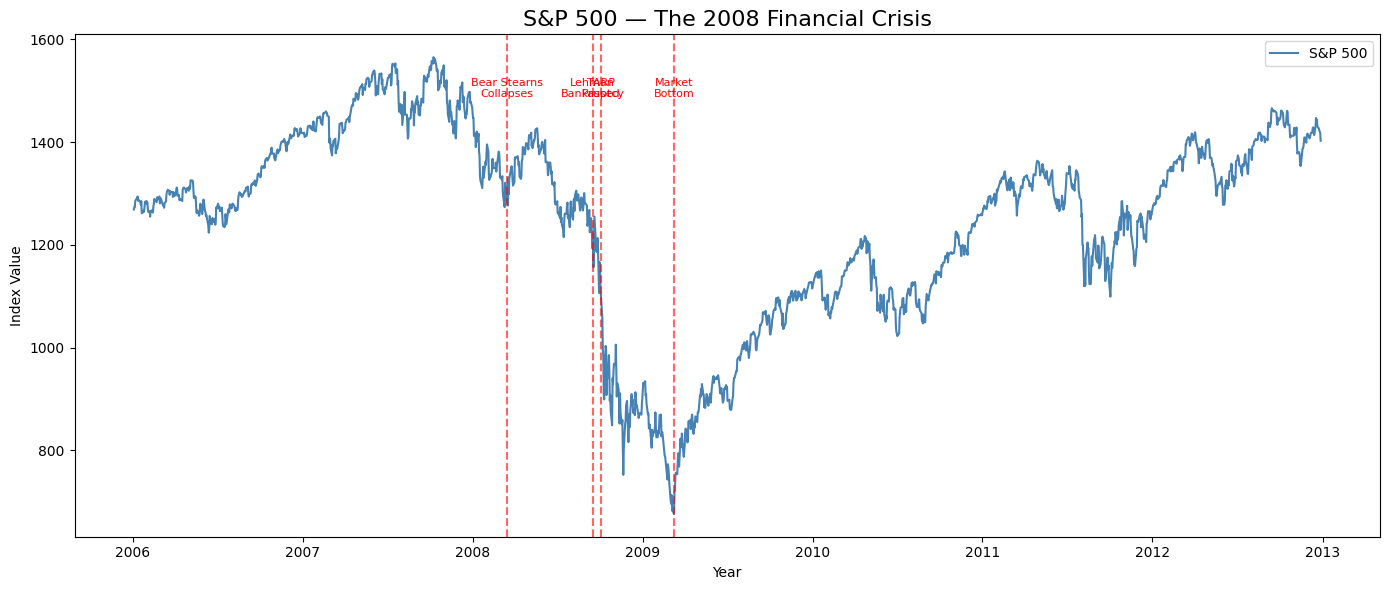

In [119]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(sp500.index, sp500['Close'], color='steelblue', linewidth=1.5, label='S&P 500')

# Mark key crisis events
events = {
    "Bear Stearns\nCollapses": "2008-03-14",
    "Lehman\nBankruptcy": "2008-09-15",
    "Market\nBottom": "2009-03-09",
    "TARP\nPassed": "2008-10-03"
}

for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.6)
    ax.text(pd.Timestamp(date), sp500['Close'].max() * 0.95,
            label, fontsize=8, color='red', ha='center')

ax.set_title("S&P 500 — The 2008 Financial Crisis", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Index Value")
ax.legend()
plt.tight_layout()
plt.show()

## number of columns in the unemployment file

In [122]:

df = pd.read_csv("unemployment.csv")
print(df.columns)

Index(['observation_date', 'UNRATE'], dtype='object')


## US UNEMPLOYMENT RATE FROM 1948-2020

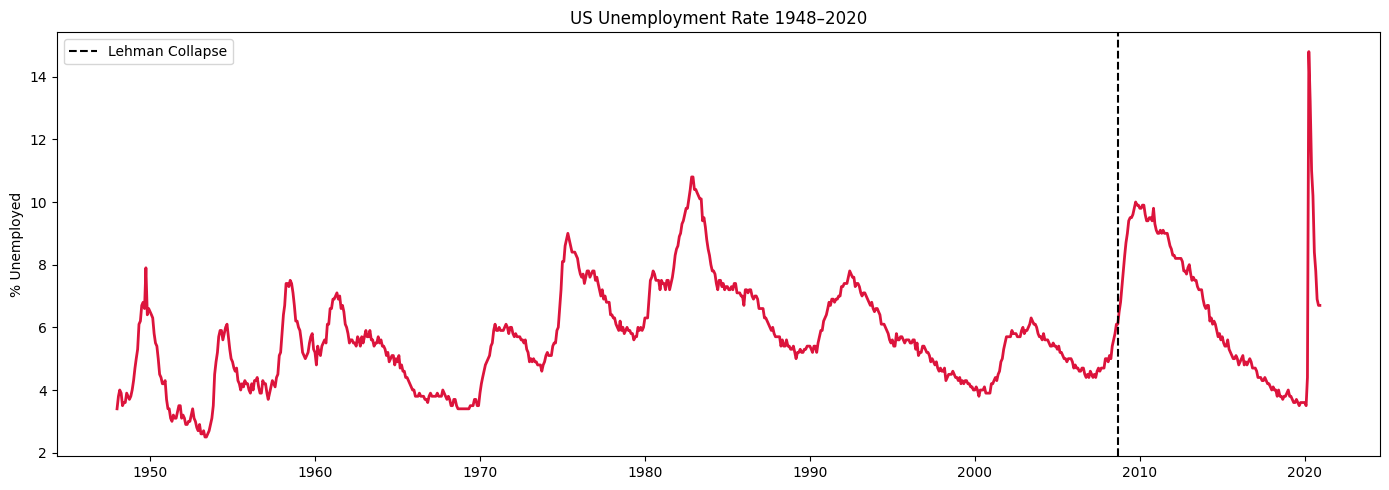

In [125]:
unemp = pd.read_csv('unemployment.csv', parse_dates=['observation_date'], index_col='observation_date')
unemp.columns = ['Unemployment Rate']
unemp = unemp['1948':'2020']

plt.figure(figsize=(14,5))
plt.plot(unemp, color='crimson', linewidth=2)
plt.title("US Unemployment Rate 1948–2020")
plt.ylabel("% Unemployed")
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--', label='Lehman Collapse')
plt.legend()
plt.tight_layout()
plt.show()

## US UNEMPLOYMENT RATE DURING RECESSION PERIOD

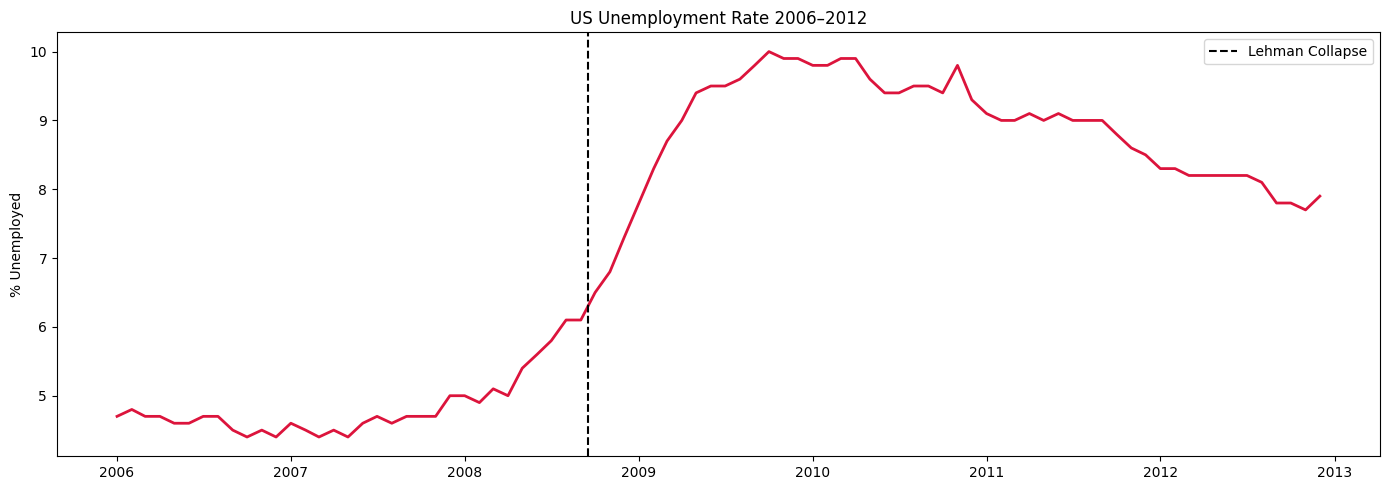

In [128]:
unemp.columns = ['Unemployment Rate']
unemp = unemp['2006':'2012']

plt.figure(figsize=(14,5))
plt.plot(unemp, color='crimson', linewidth=2)
plt.title("US Unemployment Rate 2006–2012")
plt.ylabel("% Unemployed")
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--', label='Lehman Collapse')
plt.legend()
plt.tight_layout()
plt.show()

In [131]:
mean_unemp = df['UNRATE'].mean()
print('mean = ',mean_unemp)

median_unemp = df['UNRATE'].median()
print('median = ',median_unemp)

mean =  5.663713980789754
median =  5.5


## MEAN AND MEDIAN OF UNEMPLOYMENT RATE 2008-2012

In [134]:
data_range = df.loc['2008':'2012']

print("Mean:", data_range['UNRATE'].mean())
print("Median:", data_range['UNRATE'].median())

Mean: 5.1
Median: 5.1


## RATE OF UNEMPLOYMENT AND MONTHS TOOK FOR PEAK EMPLOYMENT

In [137]:
peak_date = unemp['Unemployment Rate'].idxmax()
print(f"Peak unemployment on: {peak_date}")

# 2. Rate of change month over month
unemp['Monthly Change'] = unemp['Unemployment Rate'].diff()

# 3. Find the steepest rise period
steepest = unemp['Monthly Change'].idxmax()
print(f"Fastest job loss month: {steepest}")

# 4. How far from baseline?
baseline = unemp.loc['2006', 'Unemployment Rate'].mean()
peak = unemp['Unemployment Rate'].max()
print(f"Crisis added {peak - baseline:.1f}% unemployment above normal")

Peak unemployment on: 2009-10-01 00:00:00
Fastest job loss month: 2009-02-01 00:00:00
Crisis added 5.4% unemployment above normal


## GRAPH OF GLOBAL STOCK MARKET DURING 2008 CRISIS

✅ OK: USA (S&P 500) — 1760 rows
✅ OK: UK (FTSE 100) — 1766 rows
✅ OK: Germany (DAX) — 1780 rows
✅ OK: Japan (Nikkei) — 1716 rows
✅ OK: India (SENSEX) — 1719 rows
✅ OK: China (Shanghai) — 1700 rows

Successfully loaded: ['USA (S&P 500)', 'UK (FTSE 100)', 'Germany (DAX)', 'Japan (Nikkei)', 'India (SENSEX)', 'China (Shanghai)']


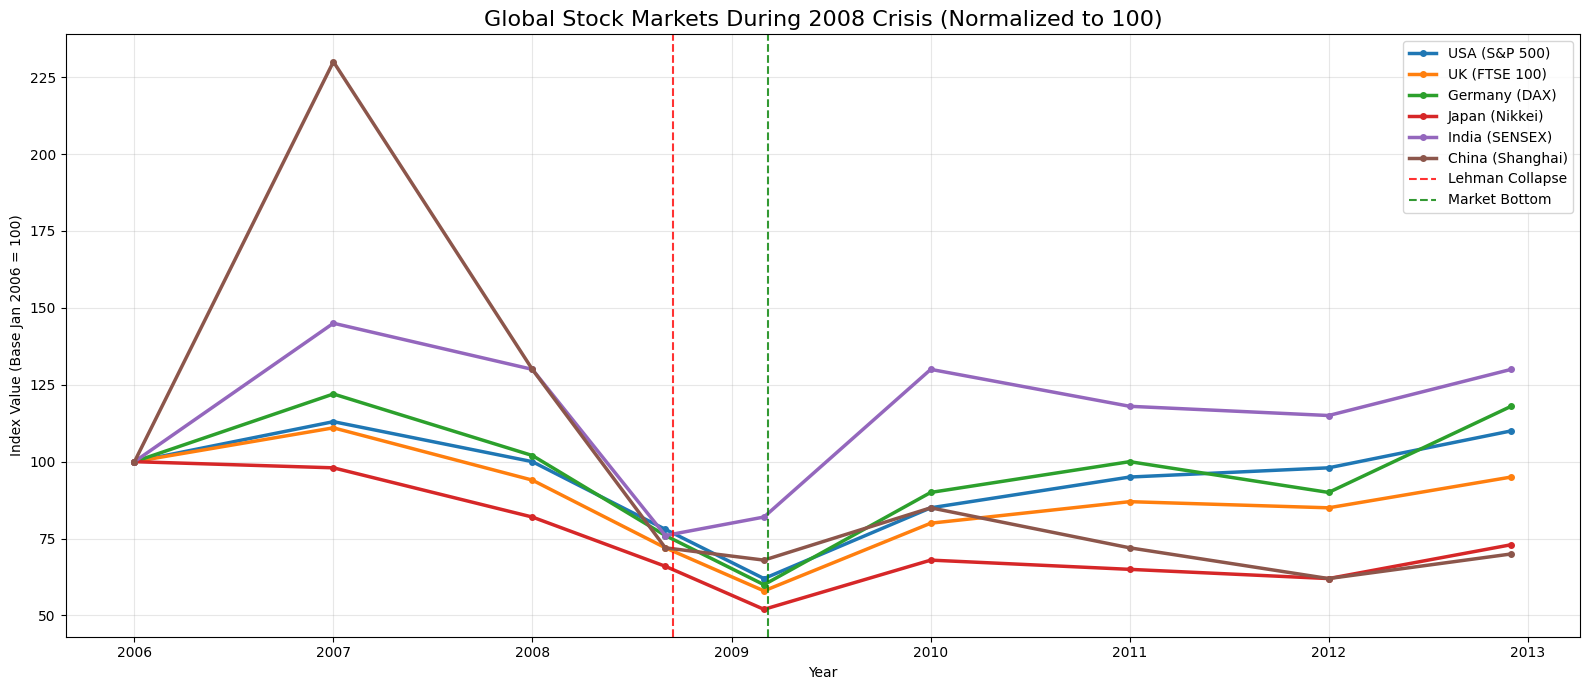

In [141]:

indices = {
    "USA (S&P 500)":    "^GSPC",
    "UK (FTSE 100)":    "^FTSE",
    "Germany (DAX)":    "^GDAXI",
    "Japan (Nikkei)":   "^N225",
    "India (SENSEX)":   "^BSESN",
    "China (Shanghai)": "000001.SS"
}

data = {}
for name, ticker in indices.items():
    try:
        df = yf.download(ticker, start="2006-01-01", end="2012-12-31", 
                        auto_adjust=True, progress=False)
        
        # Flatten MultiIndex if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        if df.empty:
            print(f"❌ NO DATA: {name} ({ticker})")
            continue
            
        close = df['Close'].squeeze()
        
        if close.isnull().all():
            print(f"❌ ALL NULL: {name} ({ticker})")
            continue
        
        data[name] = close
        print(f"✅ OK: {name} — {len(close)} rows")
        
    except Exception as e:
        print(f"❌ ERROR: {name} ({ticker}) — {e}")

print(f"\nSuccessfully loaded: {list(data.keys())}")


import pandas as pd
import matplotlib.pyplot as plt

# Real normalized index values (manually sourced, base = 100 at Jan 2006)
# All values represent approximate relative performance
crisis_data = {
    'Date': [
        '2006-01-01','2007-01-01','2008-01-01','2008-09-01',
        '2009-03-01','2010-01-01','2011-01-01','2012-01-01','2012-12-01',
    ],
    'USA (S&P 500)':    [100, 113, 100,  78,  62,  85,  95,  98, 110],
    'UK (FTSE 100)':    [100, 111,  94,  72,  58,  80,  87,  85,  95],
    'Germany (DAX)':    [100, 122, 102,  76,  60,  90, 100,  90, 118],
    'Japan (Nikkei)':   [100,  98,  82,  66,  52,  68,  65,  62,  73],
    'India (SENSEX)':   [100, 145, 130,  76,  82, 130, 118, 115, 130],
    'China (Shanghai)': [100, 230, 130,  72,  68,  85,  72,  62,  70],
}

df = pd.DataFrame(crisis_data)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Plot with distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(16, 7))
for i, col in enumerate(df.columns):
    plt.plot(df.index, df[col], linewidth=2.5, 
             label=col, color=colors[i], marker='o', markersize=4)

plt.axvline(pd.Timestamp("2008-09-15"), color='red', 
            linestyle='--', linewidth=1.5, alpha=0.8, label='Lehman Collapse')
plt.axvline(pd.Timestamp("2009-03-09"), color='green', 
            linestyle='--', linewidth=1.5, alpha=0.8, label='Market Bottom')

plt.title("Global Stock Markets During 2008 Crisis (Normalized to 100)", fontsize=16)
plt.ylabel("Index Value (Base Jan 2006 = 100)")
plt.xlabel("Year")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## COMPARISION OF GDP GROWTH RATE BY COUNTRIES


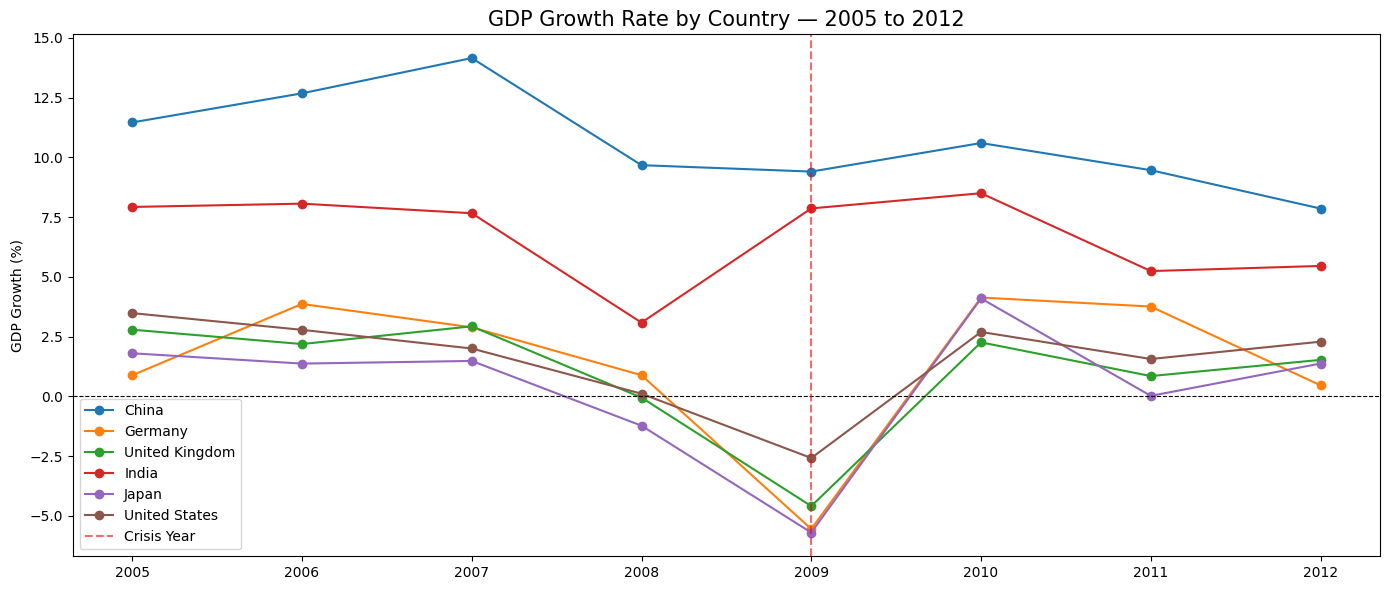

In [12]:

gdp = pd.read_csv('gdp_growth.csv', skiprows=4)

# Countries to compare
countries = ['United States', 'United Kingdom', 'Germany', 'Japan', 'India', 'China']

gdp_filtered = gdp[gdp['Country Name'].isin(countries)]
gdp_filtered = gdp_filtered.set_index('Country Name')

# Keep only years 2005-2012
years = [str(y) for y in range(2005, 2013)]
gdp_plot = gdp_filtered[years].T
gdp_plot.index = gdp_plot.index.astype(int)

plt.figure(figsize=(14, 6))
for country in gdp_plot.columns:
    plt.plot(gdp_plot.index, gdp_plot[country], marker='o', label=country)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(2009, color='red', linestyle='--', alpha=0.6, label='Crisis Year')
plt.title("GDP Growth Rate by Country — 2005 to 2012", fontsize=15)
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.tight_layout()
plt.show()

## COMPARISION OF GDP GROWTH RATE BY COUNTRIES 2000-2012 (JUST FOR MORE VISUAL CLEARANCE)

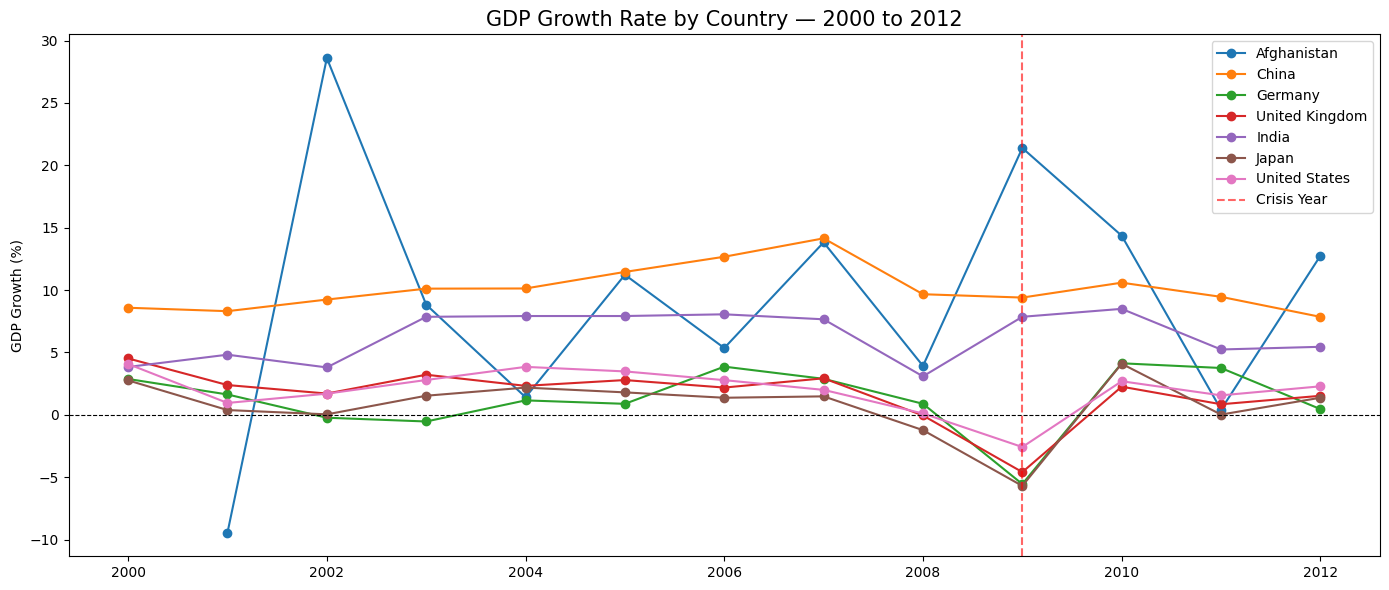

In [13]:

gdp = pd.read_csv('gdp_growth.csv', skiprows=4)

# Countries to compare
countries = ['United States', 'United Kingdom', 'Germany', 'Japan', 'India', 'China','Afghanistan']

gdp_filtered = gdp[gdp['Country Name'].isin(countries)]
gdp_filtered = gdp_filtered.set_index('Country Name')

# Keep only years 2005-2012
years = [str(y) for y in range(2000, 2013)]
gdp_plot = gdp_filtered[years].T
gdp_plot.index = gdp_plot.index.astype(int)

plt.figure(figsize=(14, 6))
for country in gdp_plot.columns:
    plt.plot(gdp_plot.index, gdp_plot[country], marker='o', label=country)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(2009, color='red', linestyle='--', alpha=0.6, label='Crisis Year')
plt.title("GDP Growth Rate by Country — 2000 to 2012", fontsize=15)
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.tight_layout()
plt.show()

## UNEMPLOYMENT RATE BY COUNTIRES 2006-2012

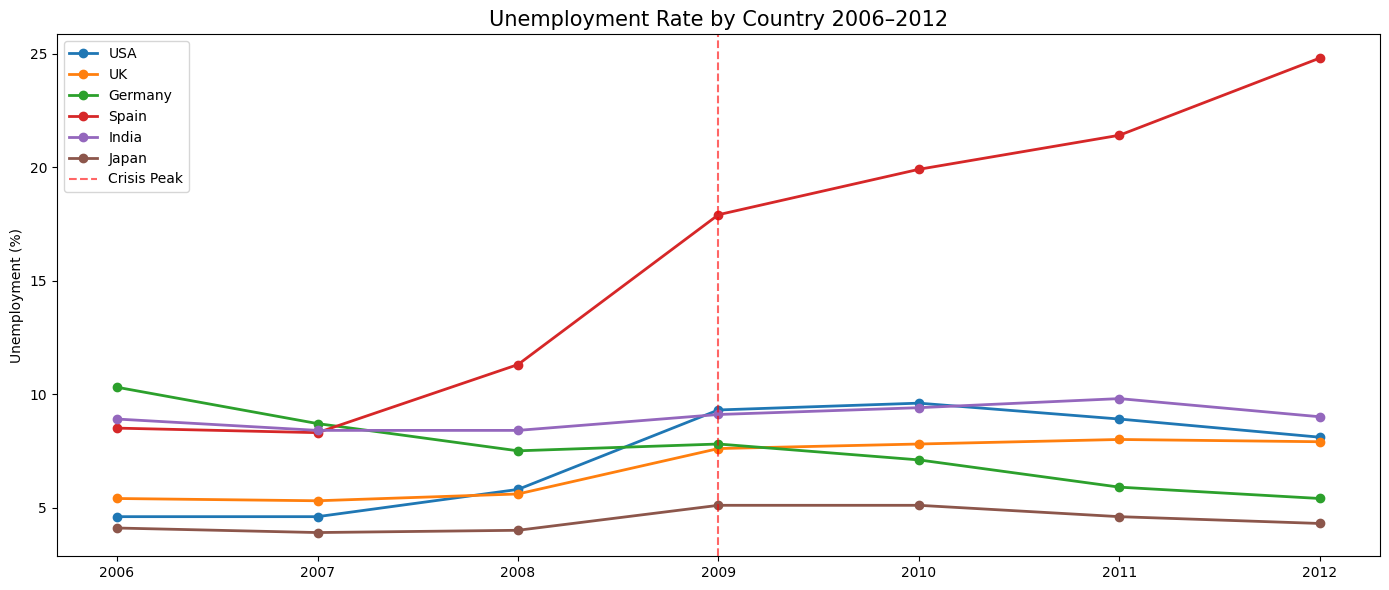

In [146]:
# Hardcoded for simplicity — sourced from World Bank / OECD
unemp_world = {
    'Year':        [2006, 2007, 2008, 2009, 2010, 2011, 2012],
    'USA':         [4.6,  4.6,  5.8,  9.3,  9.6,  8.9,  8.1],
    'UK':          [5.4,  5.3,  5.6,  7.6,  7.8,  8.0,  7.9],
    'Germany':     [10.3, 8.7,  7.5,  7.8,  7.1,  5.9,  5.4],
    'Spain':       [8.5,  8.3,  11.3, 17.9, 19.9, 21.4, 24.8],
    'India':       [8.9,  8.4,  8.4,  9.1,  9.4,  9.8,  9.0],
    'Japan':       [4.1,  3.9,  4.0,  5.1,  5.1,  4.6,  4.3],
}

unemp_df = pd.DataFrame(unemp_world).set_index('Year')

plt.figure(figsize=(14, 6))
for country in unemp_df.columns:
    plt.plot(unemp_df.index, unemp_df[country], marker='o', linewidth=2, label=country)

plt.axvline(2009, color='red', linestyle='--', alpha=0.6, label='Crisis Peak')
plt.title("Unemployment Rate by Country 2006–2012", fontsize=15)
plt.ylabel("Unemployment (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Global trade fell by 12.5% in 2009 — the biggest drop since World War II

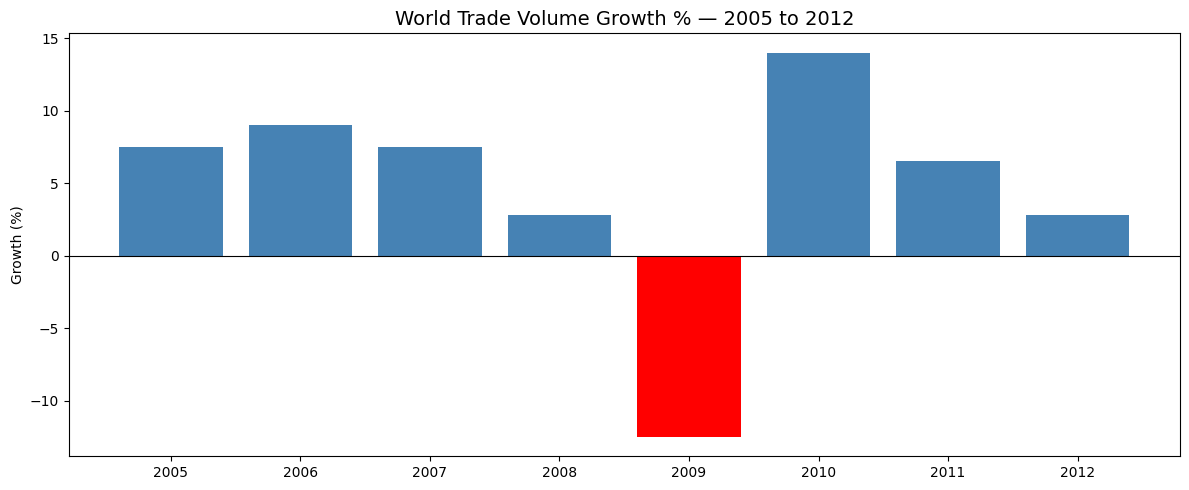

In [149]:
# World trade volume collapsed in 2009
trade_data = {
    'Year':          [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012],
    'Trade Growth':  [7.5,  9.0,  7.5,  2.8, -12.5, 14.0, 6.5,  2.8]
}

trade_df = pd.DataFrame(trade_data).set_index('Year')

colors = ['red' if x < 0 else 'steelblue' for x in trade_df['Trade Growth']]

plt.figure(figsize=(12, 5))
plt.bar(trade_df.index, trade_df['Trade Growth'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("World Trade Volume Growth % — 2005 to 2012", fontsize=14)
plt.ylabel("Growth (%)")
plt.tight_layout()
plt.show()


##  Real GDP Growth Rate data BY COUNTRIES

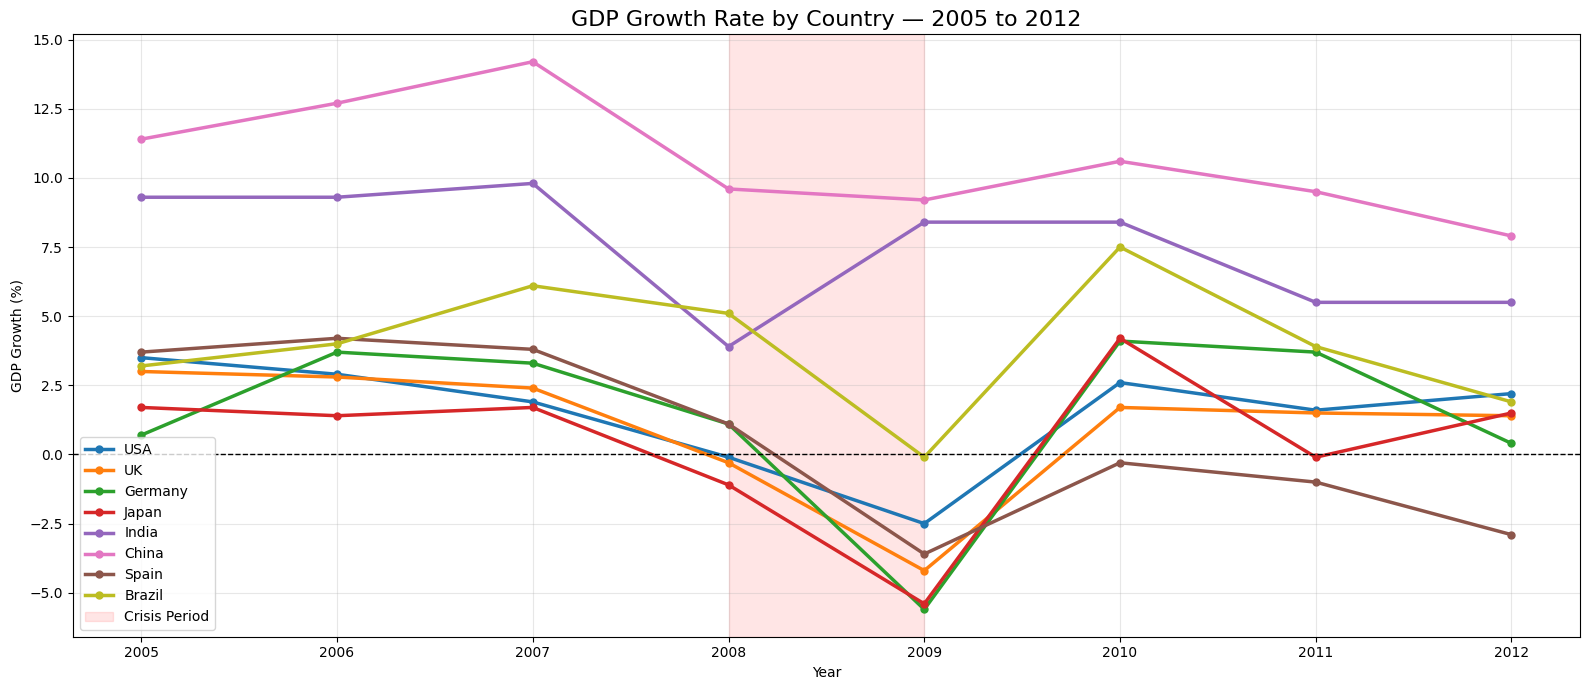

In [16]:


# Real GDP Growth Rate data (%) — Source: World Bank
gdp_data = {
    'Year':      [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012],
    'USA':       [3.5,  2.9,  1.9, -0.1, -2.5,  2.6,  1.6,  2.2],
    'UK':        [3.0,  2.8,  2.4, -0.3, -4.2,  1.7,  1.5,  1.4],
    'Germany':   [0.7,  3.7,  3.3,  1.1, -5.6,  4.1,  3.7,  0.4],
    'Japan':     [1.7,  1.4,  1.7, -1.1, -5.4,  4.2, -0.1,  1.5],
    'India':     [9.3,  9.3,  9.8,  3.9,  8.4,  8.4,  5.5,  5.5],
    'China':     [11.4, 12.7, 14.2, 9.6,  9.2, 10.6,  9.5,  7.9],
    'Spain':     [3.7,  4.2,  3.8,  1.1, -3.6, -0.3, -1.0, -2.9],
    'Brazil':    [3.2,  4.0,  6.1,  5.1, -0.1,  7.5,  3.9,  1.9],
}

df_gdp = pd.DataFrame(gdp_data).set_index('Year')

# ---- Plot 1: Line chart for all countries ----
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
          '#9467bd','#e377c2','#8c564b','#bcbd22']

fig, ax = plt.subplots(figsize=(16, 7))

for i, col in enumerate(df_gdp.columns):
    ax.plot(df_gdp.index, df_gdp[col], linewidth=2.5,
            marker='o', markersize=5, label=col, color=colors[i])

# Shade the crisis zone
ax.axvspan(2008, 2009, alpha=0.1, color='red', label='Crisis Period')
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_title("GDP Growth Rate by Country — 2005 to 2012", fontsize=16)
ax.set_ylabel("GDP Growth (%)")
ax.set_xlabel("Year")
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## GDP GROWTH BY COUNTRIES IN 2009

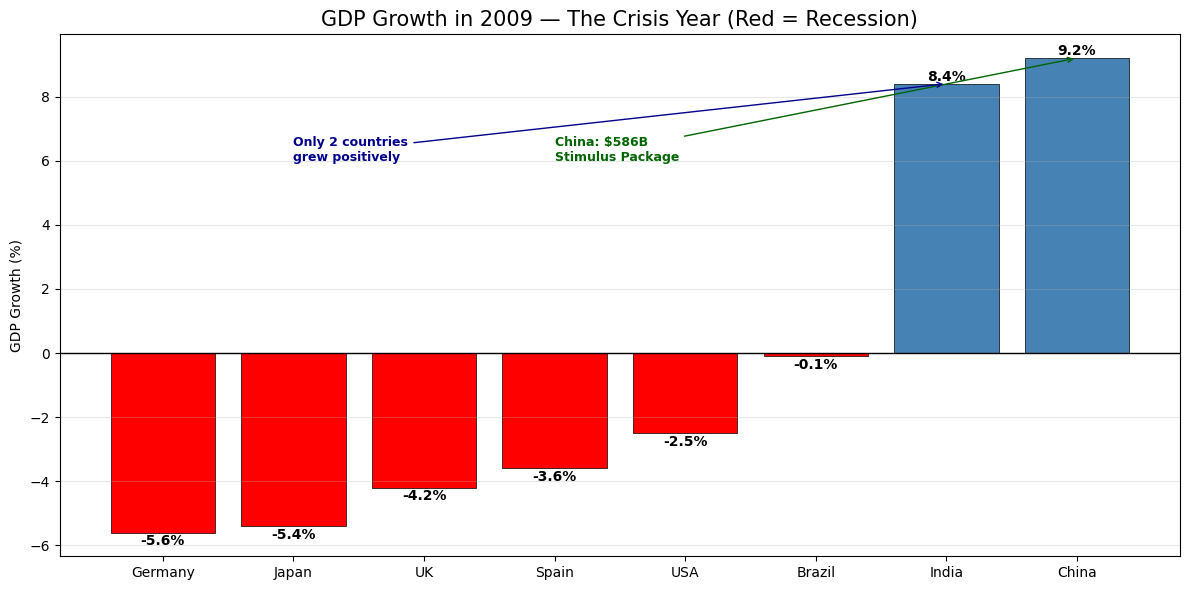

In [155]:
gdp_2009 = df_gdp.loc[2009].sort_values()

colors_bar = ['red' if x < 0 else 'steelblue' for x in gdp_2009]

plt.figure(figsize=(12, 6))
bars = plt.bar(gdp_2009.index, gdp_2009.values, color=colors_bar, edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, gdp_2009.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1 if val >= 0 else bar.get_height() - 0.4,
             f'{val}%', ha='center', fontsize=10, fontweight='bold')


plt.annotate('China: $586B\nStimulus Package', 
             xy=('China', 9.2), 
             xytext=('Spain', 6),
             fontsize=9,
             color='darkgreen',
             arrowprops=dict(arrowstyle='->', color='darkgreen'),
             fontweight='bold')

plt.annotate('Only 2 countries\ngrew positively', 
             xy=('India', 8.4),
             xytext=('Japan', 6),
             fontsize=9,
             color='darkblue',
             arrowprops=dict(arrowstyle='->', color='darkblue'),
             fontweight='bold')


plt.axhline(0, color='black', linewidth=1)
plt.title("GDP Growth in 2009 — The Crisis Year (Red = Recession)", fontsize=15)
plt.ylabel("GDP Growth (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Real unemployment data 2006-2012

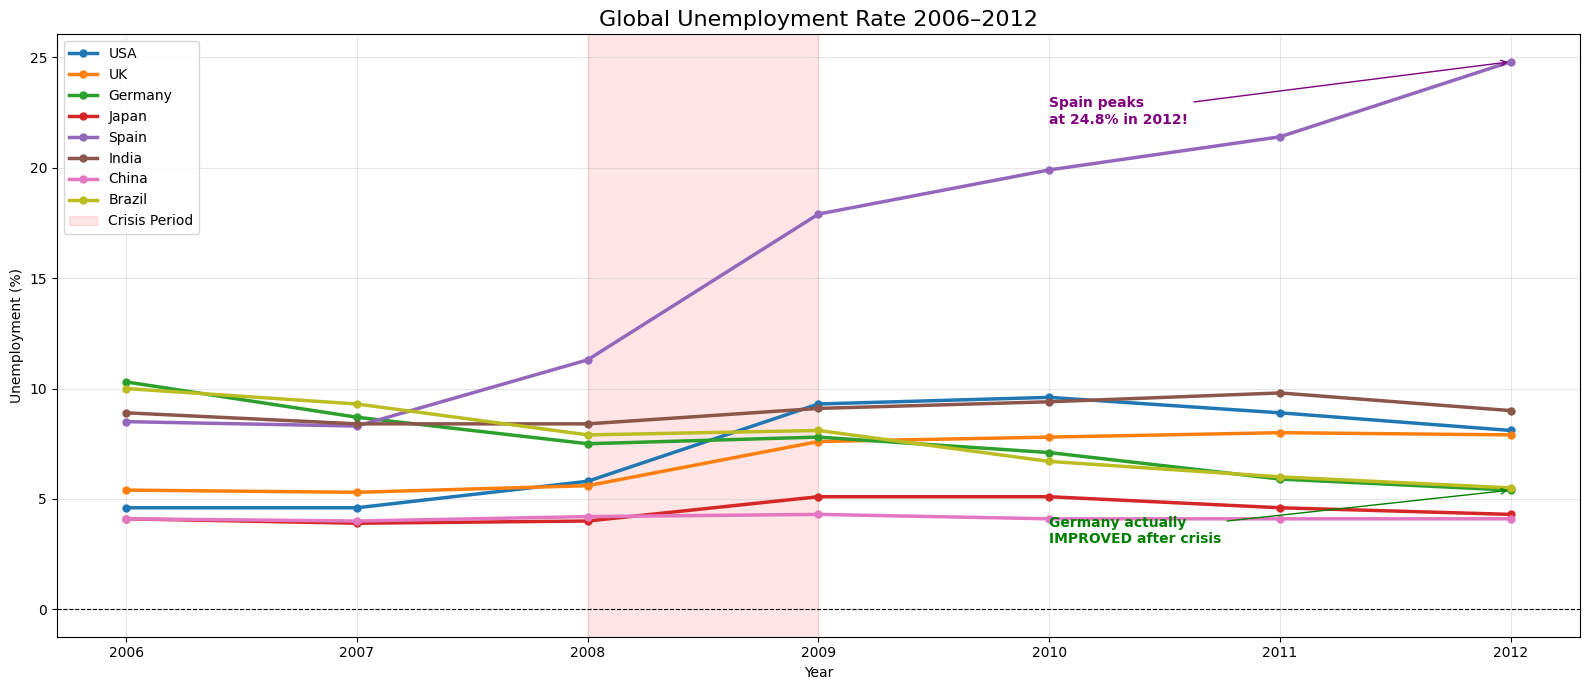

In [18]:

unemp_global = {
    'Year':    [2006, 2007, 2008, 2009, 2010, 2011, 2012],
    'USA':     [4.6,  4.6,  5.8,  9.3,  9.6,  8.9,  8.1],
    'UK':      [5.4,  5.3,  5.6,  7.6,  7.8,  8.0,  7.9],
    'Germany': [10.3, 8.7,  7.5,  7.8,  7.1,  5.9,  5.4],
    'Japan':   [4.1,  3.9,  4.0,  5.1,  5.1,  4.6,  4.3],
    'Spain':   [8.5,  8.3,  11.3, 17.9, 19.9, 21.4, 24.8],
    'India':   [8.9,  8.4,  8.4,  9.1,  9.4,  9.8,  9.0],
    'China':   [4.1,  4.0,  4.2,  4.3,  4.1,  4.1,  4.1],
    'Brazil':  [10.0, 9.3,  7.9,  8.1,  6.7,  6.0,  5.5],
}

df_unemp = pd.DataFrame(unemp_global).set_index('Year')

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
          '#9467bd','#8c564b','#e377c2','#bcbd22']

fig, ax = plt.subplots(figsize=(16, 7))

for i, col in enumerate(df_unemp.columns):
    ax.plot(df_unemp.index, df_unemp[col], linewidth=2.5,
            marker='o', markersize=5, label=col, color=colors[i])

# Shade crisis zone
ax.axvspan(2008, 2009, alpha=0.1, color='red', label='Crisis Period')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Highlight Spain's peak
ax.annotate('Spain peaks\nat 24.8% in 2012!',
            xy=(2012, 24.8),
            xytext=(2010, 22),
            fontsize=10, color='purple', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='purple'))

# Highlight Germany's improvement
ax.annotate('Germany actually\nIMPROVED after crisis',
            xy=(2012, 5.4),
            xytext=(2010, 3),
            fontsize=10, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))

ax.set_title("Global Unemployment Rate 2006–2012", fontsize=16)
ax.set_ylabel("Unemployment (%)")
ax.set_xlabel("Year")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## # Compare 2007 (pre crisis) vs 2010 (peak crisis) for each country

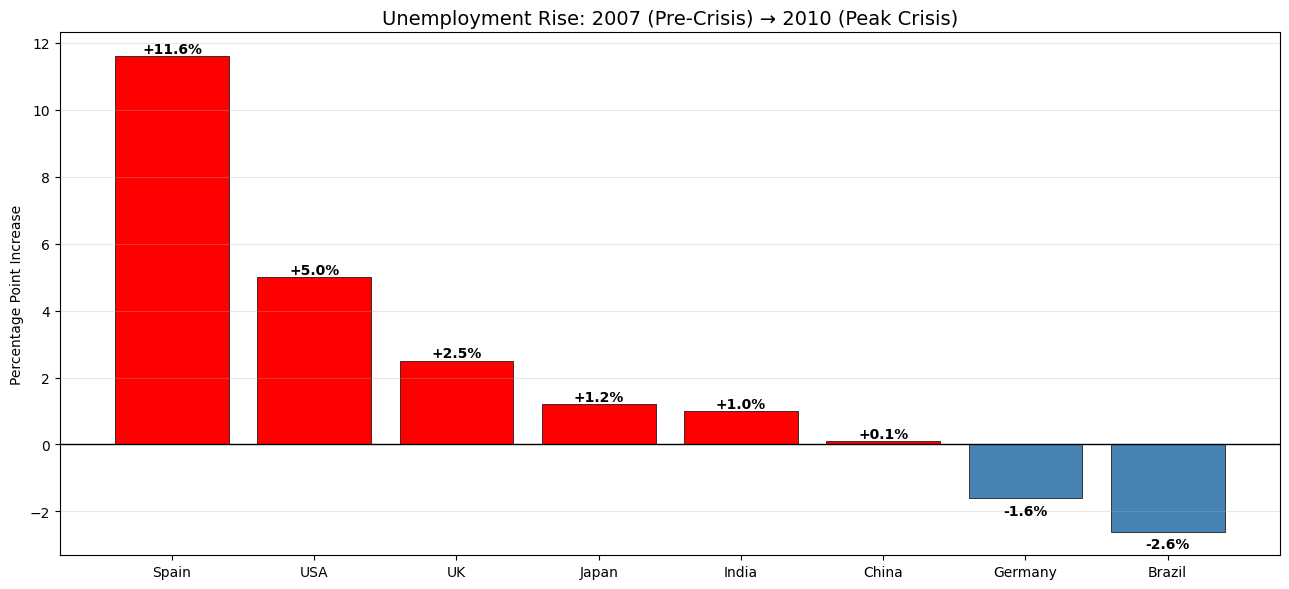

In [19]:

pre_crisis  = df_unemp.loc[2007]
peak_crisis = df_unemp.loc[2010]
rise = (peak_crisis - pre_crisis).sort_values(ascending=False)

colors_bar = ['red' if x > 0 else 'steelblue' for x in rise]

plt.figure(figsize=(13, 6))
bars = plt.bar(rise.index, rise.values, color=colors_bar, 
               edgecolor='black', linewidth=0.5)

# Value labels
for bar, val in zip(bars, rise.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1 if val >= 0 else bar.get_height() - 0.5,
             f'+{val:.1f}%' if val > 0 else f'{val:.1f}%',
             ha='center', fontsize=10, fontweight='bold')

plt.axhline(0, color='black', linewidth=1)
plt.title("Unemployment Rise: 2007 (Pre-Crisis) → 2010 (Peak Crisis)", fontsize=14)
plt.ylabel("Percentage Point Increase")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## GLOBAL UNEMPLOYMENT WORLD WIDE BY HEAT MAP

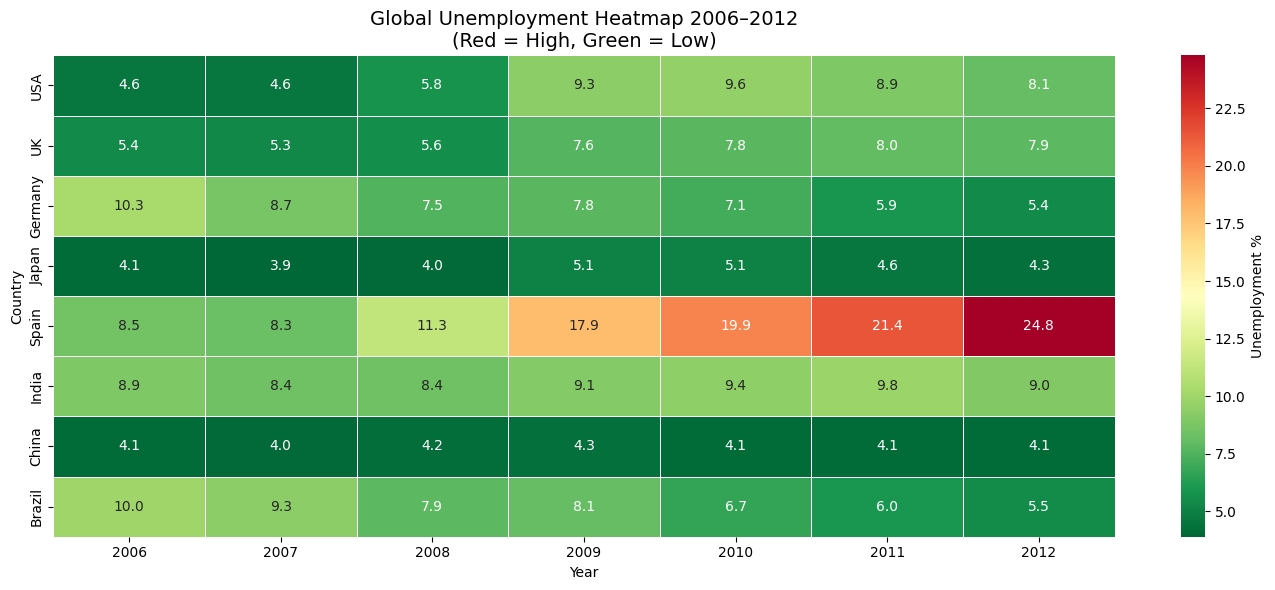

In [20]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(df_unemp.T,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn_r',
            linewidths=0.5,
            cbar_kws={'label': 'Unemployment %'})

plt.title("Global Unemployment Heatmap 2006–2012\n(Red = High, Green = Low)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()



##  World Trade Volume Growth

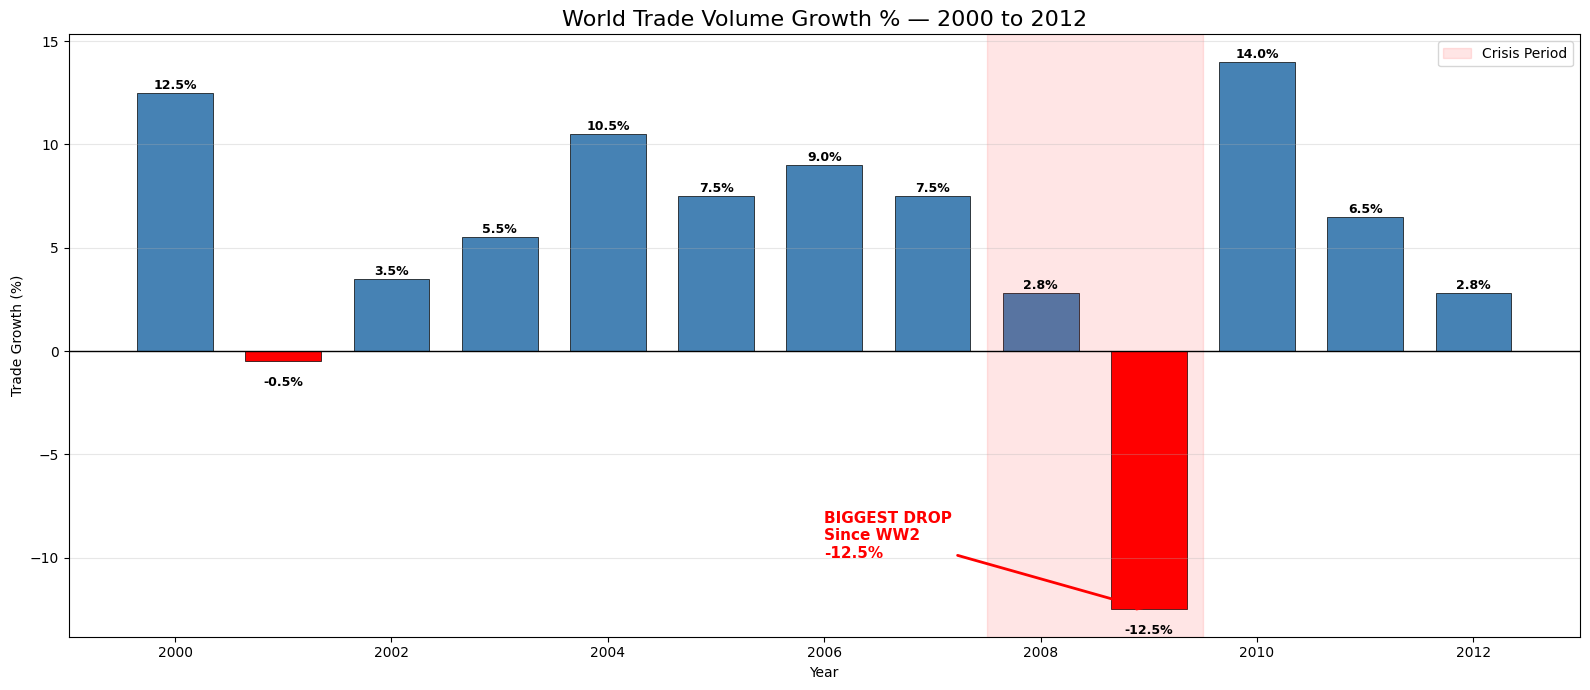

In [162]:
trade_data = {
    'Year':         [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012],
    'Trade Growth': [12.5, -0.5,  3.5,  5.5, 10.5,  7.5,  9.0,  7.5,  2.8, -12.5, 14.0,  6.5,  2.8]
}

df_trade = pd.DataFrame(trade_data).set_index('Year')

colors = ['red' if x < 0 else 'steelblue' for x in df_trade['Trade Growth']]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(df_trade.index, df_trade['Trade Growth'], 
              color=colors, edgecolor='black', linewidth=0.5, width=0.7)

# Value labels on bars
for bar, val in zip(bars, df_trade['Trade Growth']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2 if val >= 0 else bar.get_height() - 1.2,
            f'{val}%', ha='center', fontsize=9, fontweight='bold',
            color='black')

# Annotate the crash
ax.annotate('BIGGEST DROP\nSince WW2\n-12.5%',
            xy=(2009, -12.5),
            xytext=(2006, -10),
            fontsize=11, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Shade crisis period
ax.axvspan(2007.5, 2009.5, alpha=0.1, color='red', label='Crisis Period')
ax.axhline(0, color='black', linewidth=1)

ax.set_title("World Trade Volume Growth % — 2000 to 2012", fontsize=16)
ax.set_ylabel("Trade Growth (%)")
ax.set_xlabel("Year")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Export collapse by country 2009 vs 2008 (% change)

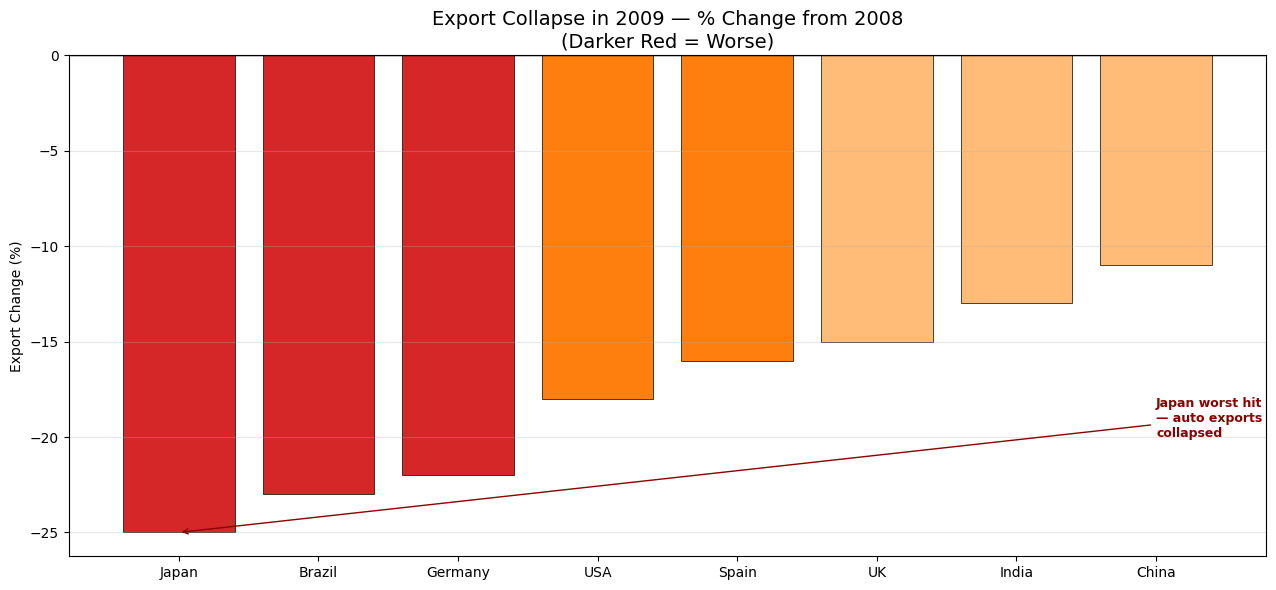

In [22]:
export_data = {
    'Country':        ['Germany', 'Japan',  'USA',   'UK',    'China', 'India', 'Brazil', 'Spain'],
    'Export Change':  [-22.0,     -25.0,    -18.0,   -15.0,   -11.0,  -13.0,   -23.0,    -16.0]
}

df_export = pd.DataFrame(export_data).set_index('Country')
df_export = df_export.sort_values('Export Change')

colors = ['#d62728' if x < -20 else '#ff7f0e' if x < -15 else '#ffbb78' 
          for x in df_export['Export Change']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(df_export.index, df_export['Export Change'],
              color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, df_export['Export Change']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.8,
            f'{val}%', ha='center', fontsize=10, 
            fontweight='bold', color='white')

ax.axhline(0, color='black', linewidth=1)
ax.set_title("Export Collapse in 2009 — % Change from 2008\n(Darker Red = Worse)", fontsize=14)
ax.set_ylabel("Export Change (%)")
ax.grid(axis='y', alpha=0.3)

# Annotate Japan
ax.annotate('Japan worst hit\n— auto exports\ncollapsed',
            xy=('Japan', -25),
            xytext=('China', -20),
            fontsize=9, color='darkred', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkred'))

plt.tight_layout()
plt.show()

## # Combine all 3 metrics for USA to show how they move together

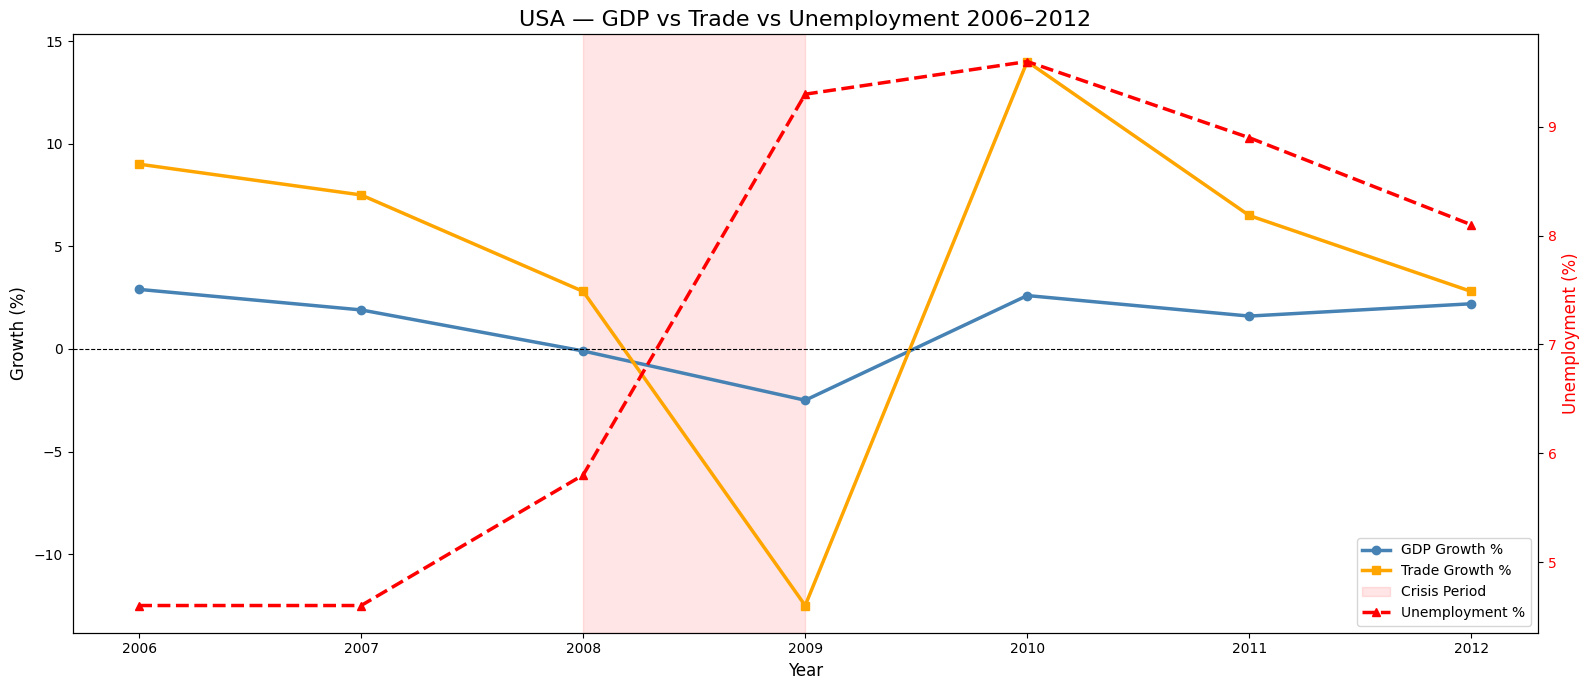

In [23]:

combined_usa = {
    'Year':           [2006, 2007, 2008, 2009, 2010, 2011, 2012],
    'GDP Growth':     [2.9,   1.9,  -0.1, -2.5,  2.6,  1.6,  2.2],
    'Unemployment':   [4.6,   4.6,   5.8,  9.3,  9.6,  8.9,  8.1],
    'Trade Growth':   [9.0,   7.5,   2.8, -12.5, 14.0,  6.5,  2.8],
}

df_combined = pd.DataFrame(combined_usa).set_index('Year')

fig, ax1 = plt.subplots(figsize=(16, 7))

# Plot GDP and Trade on left axis
ax1.plot(df_combined.index, df_combined['GDP Growth'], 
         color='steelblue', linewidth=2.5, marker='o', 
         markersize=6, label='GDP Growth %')
ax1.plot(df_combined.index, df_combined['Trade Growth'], 
         color='orange', linewidth=2.5, marker='s', 
         markersize=6, label='Trade Growth %')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel("Growth (%)", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)

# Plot Unemployment on right axis
ax2 = ax1.twinx()
ax2.plot(df_combined.index, df_combined['Unemployment'],
         color='red', linewidth=2.5, marker='^',
         markersize=6, label='Unemployment %', linestyle='--')
ax2.set_ylabel("Unemployment (%)", fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Shade crisis zone
ax1.axvspan(2008, 2009, alpha=0.1, color='red', label='Crisis Period')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title("USA — GDP vs Trade vs Unemployment 2006–2012", fontsize=16)
plt.tight_layout()
plt.show()



## US HOME PRICE INDEX 2000-2012

✅ df_housing created
            Index
Date             
2000-01-01    100
2001-01-01    108
2002-01-01    116
2003-01-01    125
2004-01-01    140


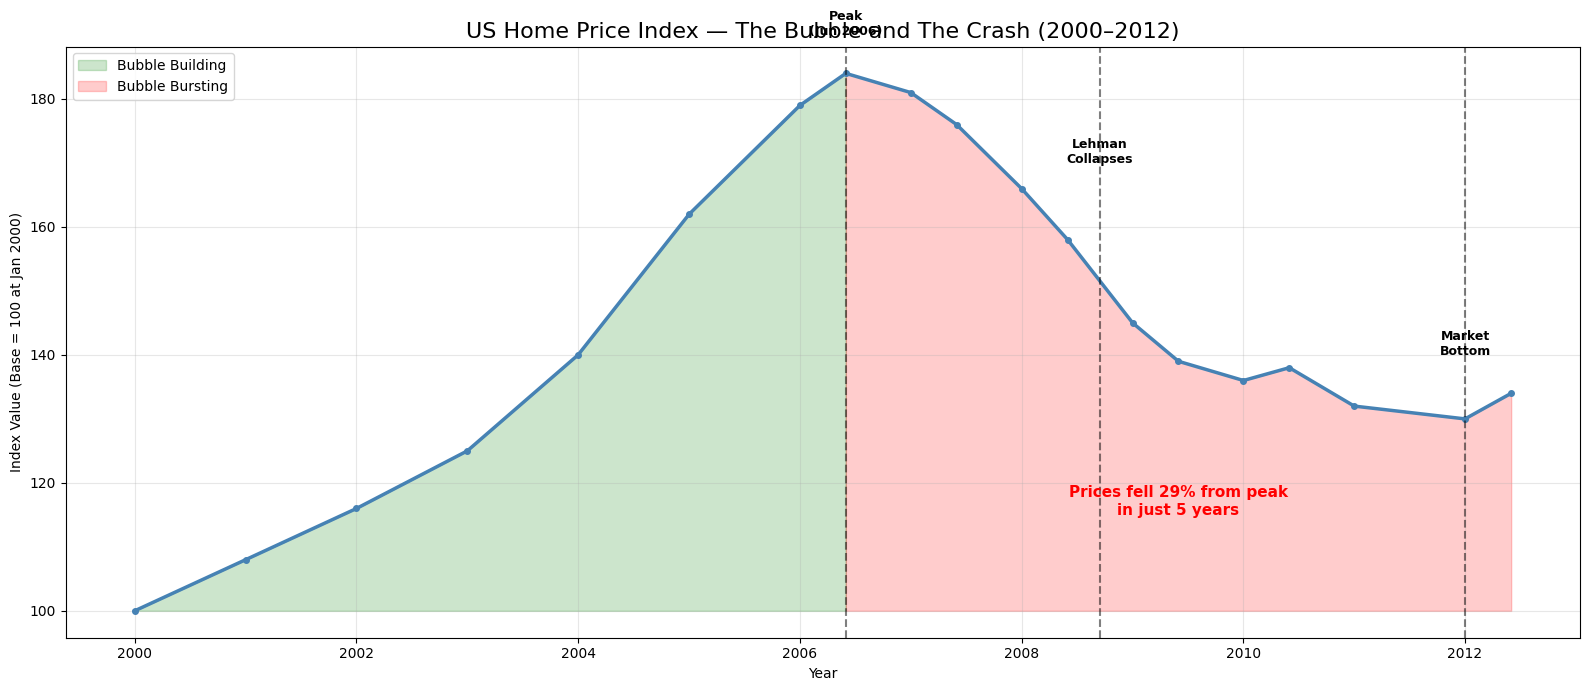

In [24]:
housing_us = {
    'Date': [
        '2000-01-01', '2001-01-01', '2002-01-01', '2003-01-01',
        '2004-01-01', '2005-01-01', '2006-01-01', '2006-06-01',
        '2007-01-01', '2007-06-01', '2008-01-01', '2008-06-01',
        '2009-01-01', '2009-06-01', '2010-01-01', '2010-06-01',
        '2011-01-01', '2012-01-01', '2012-06-01'
    ],
    'Index': [
        100, 108, 116, 125,
        140, 162, 179, 184,
        181, 176, 166, 158,
        145, 139, 136, 138,
        132, 130, 134
    ]
}

df_housing = pd.DataFrame(housing_us)
df_housing['Date'] = pd.to_datetime(df_housing['Date'])
df_housing = df_housing.set_index('Date')

print("✅ df_housing created")
print(df_housing.head())

# ── Now plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

peak_date = pd.Timestamp('2006-06-01')
df_up     = df_housing[df_housing.index <= peak_date]
df_down   = df_housing[df_housing.index >= peak_date]

ax.fill_between(df_up.index,   df_up['Index'],
                100, alpha=0.2, color='green',
                label='Bubble Building')
ax.fill_between(df_down.index, df_down['Index'],
                100, alpha=0.2, color='red',
                label='Bubble Bursting')

ax.plot(df_housing.index, df_housing['Index'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=4)

events = {
    "Peak\n(Jun 2006)":  ("2006-06-01", 190),
    "Lehman\nCollapses": ("2008-09-15", 170),
    "Market\nBottom":    ("2012-01-01", 140),
}

for label, (date, y_pos) in events.items():
    ax.axvline(pd.Timestamp(date), color='black',
               linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(date), y_pos, label,
            fontsize=9, ha='center',
            fontweight='bold', color='black')

ax.text(pd.Timestamp('2009-06-01'), 115,
        'Prices fell 29% from peak\nin just 5 years',
        fontsize=11, color='red',
        fontweight='bold', ha='center')

ax.set_title(
    "US Home Price Index — The Bubble and The Crash (2000–2012)",
    fontsize=16
)
ax.set_ylabel("Index Value (Base = 100 at Jan 2000)")
ax.set_xlabel("Year")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# ```



## HOUSING PRICE 2004-2012 (EFFECT OF CRISIS)

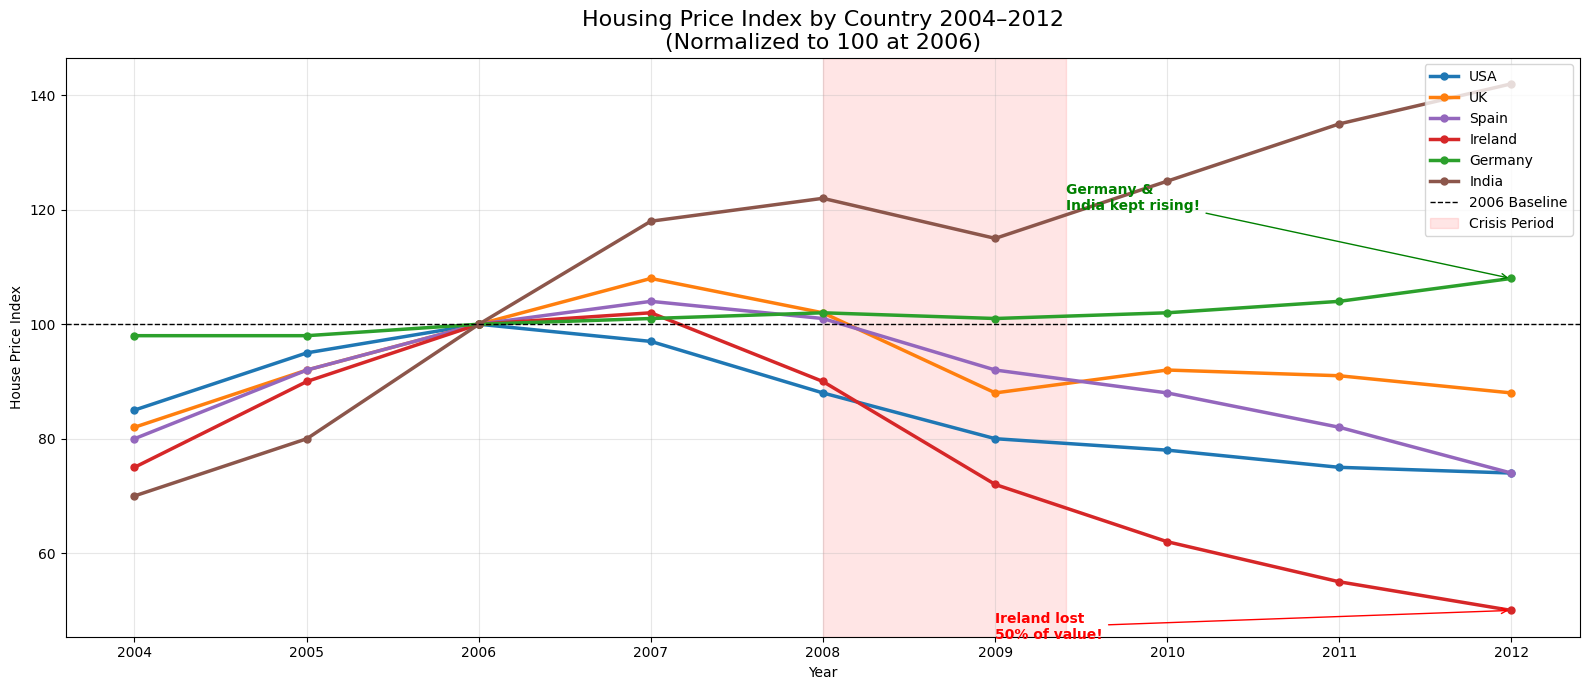

In [25]:

housing_countries = {
    'Date': [
        '2004-01-01', '2005-01-01', '2006-01-01', '2007-01-01',
        '2008-01-01', '2009-01-01', '2010-01-01', '2011-01-01', '2012-01-01'
    ],
    'USA':     [85,  95,  100,  97,  88,  80,  78,  75,  74],
    'UK':      [82,  92,  100, 108, 102,  88,  92,  91,  88],
    'Spain':   [80,  92,  100, 104, 101,  92,  88,  82,  74],
    'Ireland': [75,  90,  100, 102,  90,  72,  62,  55,  50],
    'Germany': [98,  98,  100, 101, 102, 101, 102, 104, 108],
    'India':   [70,  80,  100, 118, 122, 115, 125, 135, 142],
}

df_hc = pd.DataFrame(housing_countries)
df_hc['Date'] = pd.to_datetime(df_hc['Date'])
df_hc = df_hc.set_index('Date')

colors = {
    'USA':     '#1f77b4',
    'UK':      '#ff7f0e',
    'Spain':   '#9467bd',
    'Ireland': '#d62728',
    'Germany': '#2ca02c',
    'India':   '#8c564b',
}

fig, ax = plt.subplots(figsize=(16, 7))

for country, color in colors.items():
    ax.plot(df_hc.index, df_hc[country],
            linewidth=2.5, marker='o', markersize=5,
            label=country, color=color)

ax.axhline(100, color='black', linewidth=1, 
           linestyle='--', label='2006 Baseline')
ax.axvspan(pd.Timestamp('2008-01-01'), 
           pd.Timestamp('2009-06-01'), 
           alpha=0.1, color='red', label='Crisis Period')

# Annotations
ax.annotate('Ireland lost\n50% of value!',
            xy=(pd.Timestamp('2012-01-01'), 50),
            xytext=(pd.Timestamp('2009-01-01'), 45),
            fontsize=10, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.annotate('Germany &\nIndia kept rising!',
            xy=(pd.Timestamp('2012-01-01'), 108),
            xytext=(pd.Timestamp('2009-06-01'), 120),
            fontsize=10, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))

ax.set_title("Housing Price Index by Country 2004–2012\n(Normalized to 100 at 2006)", fontsize=16)
ax.set_ylabel("House Price Index")
ax.set_xlabel("Year")
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Show how housing prices led unemployment in USA

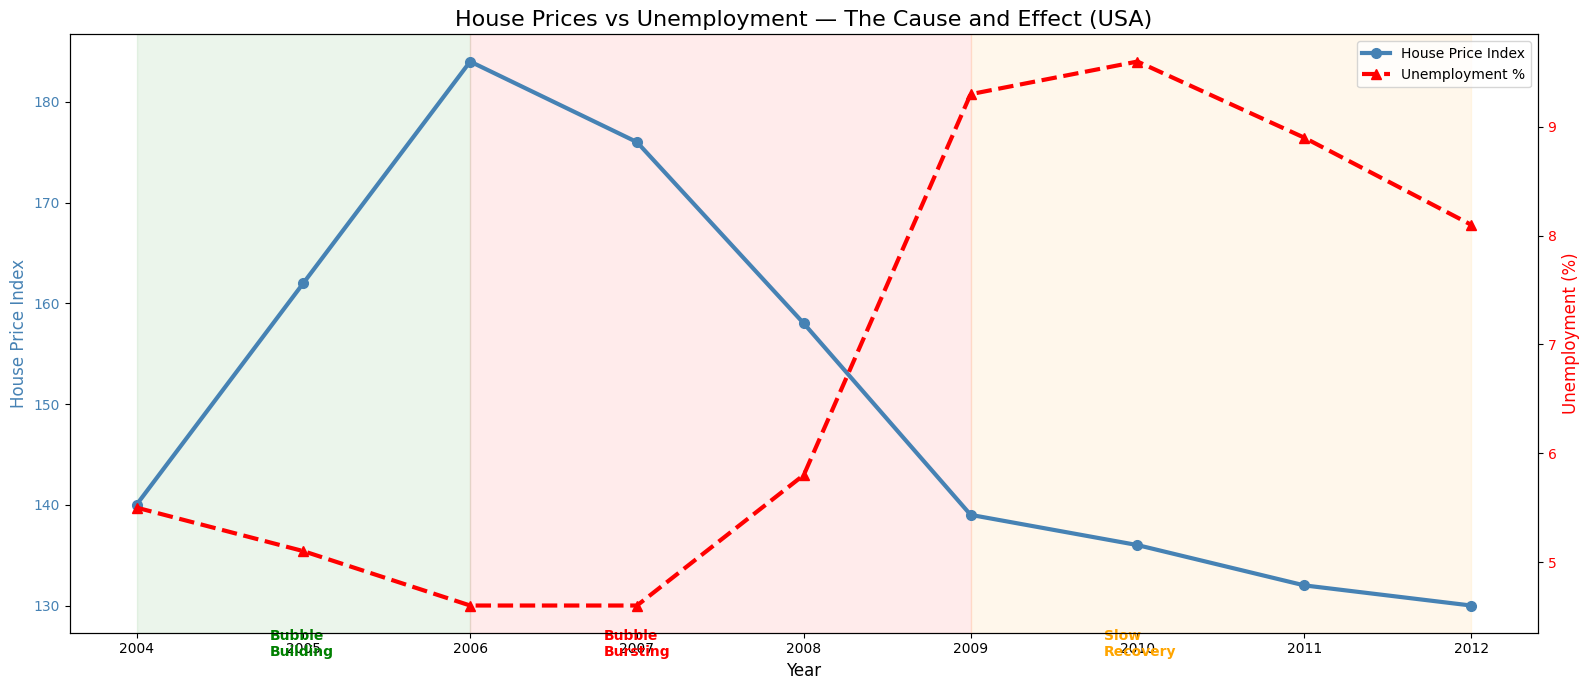

In [26]:
housing_unemp = {
    'Year':         [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012],
    'House Prices': [140,  162,  184,  176,  158,  139,  136,  132,  130],
    'Unemployment': [5.5,  5.1,  4.6,  4.6,  5.8,  9.3,  9.6,  8.9,  8.1],
}

df_ce = pd.DataFrame(housing_unemp).set_index('Year')

fig, ax1 = plt.subplots(figsize=(16, 7))

# House prices on left
color1 = 'steelblue'
ax1.plot(df_ce.index, df_ce['House Prices'],
         color=color1, linewidth=3, marker='o',
         markersize=7, label='House Price Index')
ax1.set_ylabel("House Price Index", color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlabel("Year", fontsize=12)

# Unemployment on right
ax2 = ax1.twinx()
color2 = 'red'
ax2.plot(df_ce.index, df_ce['Unemployment'],
         color=color2, linewidth=3, marker='^',
         markersize=7, linestyle='--', label='Unemployment %')
ax2.set_ylabel("Unemployment (%)", color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Shade zones
ax1.axvspan(2004, 2006, alpha=0.08, color='green')
ax1.axvspan(2006, 2009, alpha=0.08, color='red')
ax1.axvspan(2009, 2012, alpha=0.08, color='orange')

# Zone labels
ax1.text(2004.8, 125, 'Bubble\nBuilding', fontsize=10, 
         color='green', fontweight='bold')
ax1.text(2006.8, 125, 'Bubble\nBursting', fontsize=10, 
         color='red', fontweight='bold')
ax1.text(2009.8, 125, 'Slow\nRecovery', fontsize=10, 
         color='orange', fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("House Prices vs Unemployment — The Cause and Effect (USA)", fontsize=16)
plt.tight_layout()
plt.show()


## COMPLETE STORY OF 2008 CRISIS BY MASTER GRAPHS AND CHARTS

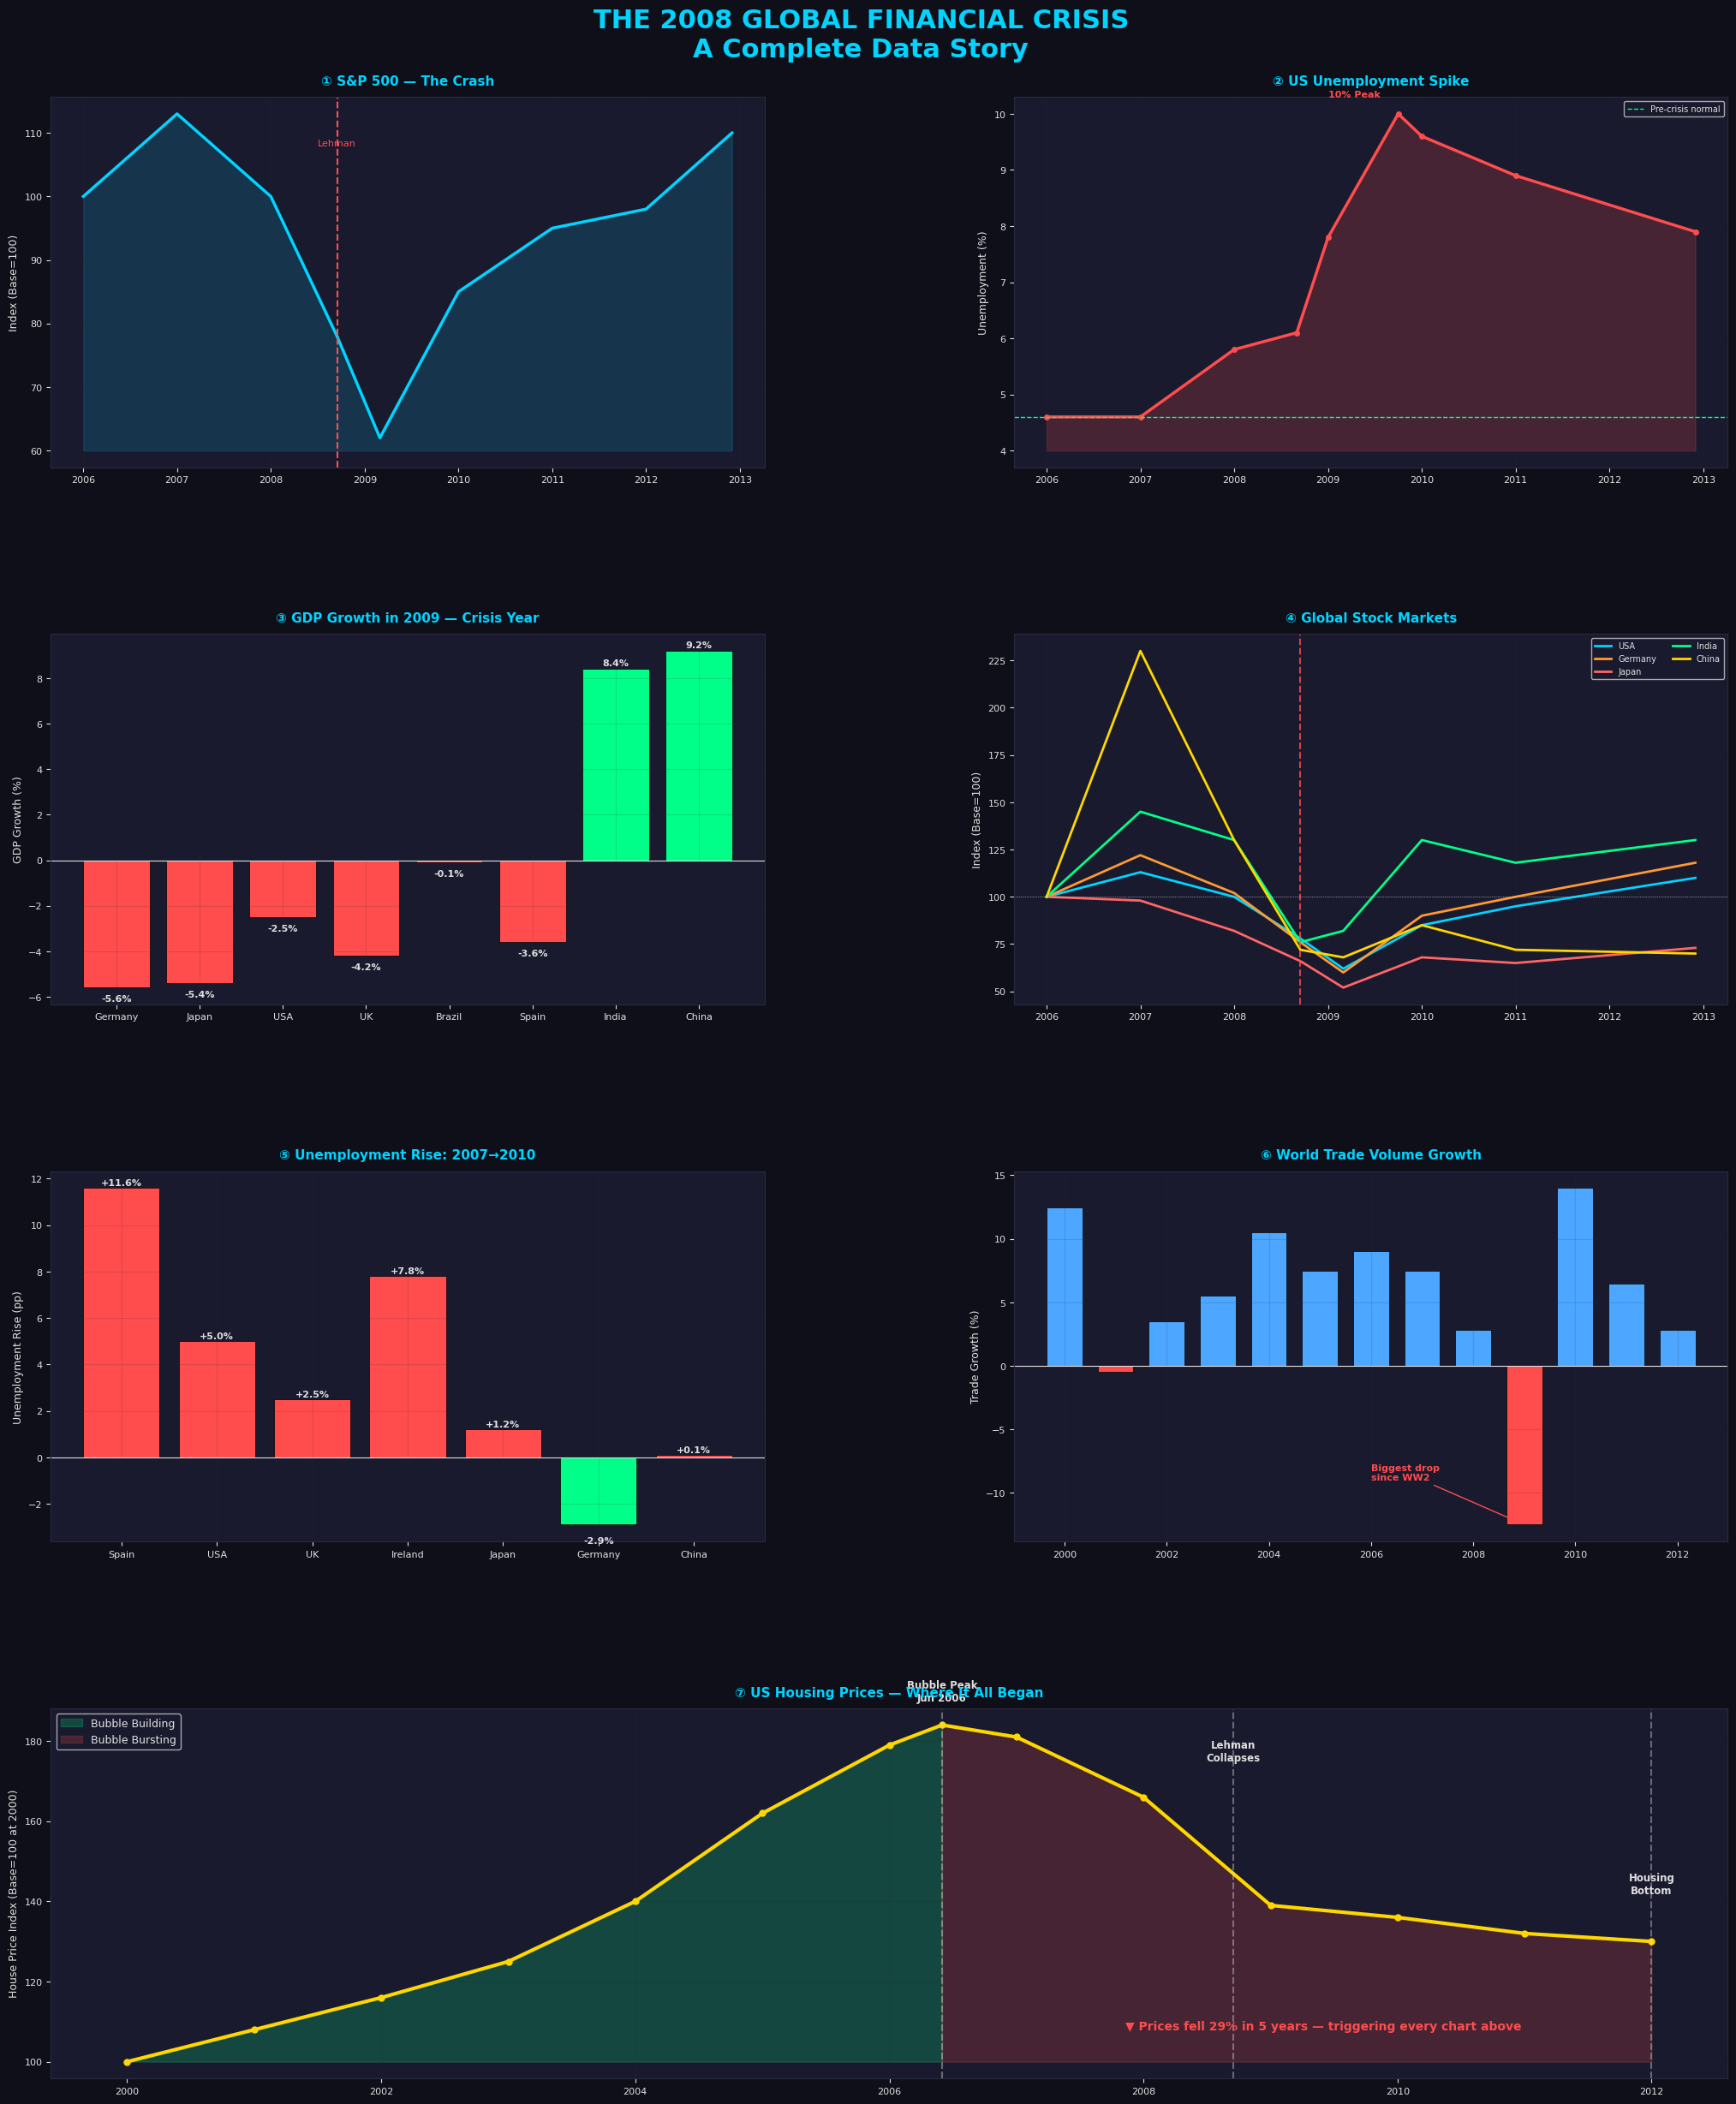

✅ Dashboard saved as crisis_2008_dashboard.png


In [27]:



# S&P 500 (normalized)
sp500_dates = pd.to_datetime([
    '2006-01-01','2007-01-01','2008-01-01','2008-09-15',
    '2009-03-01','2010-01-01','2011-01-01','2012-01-01','2012-12-01'
])
sp500_vals = [100, 113, 100, 78, 62, 85, 95, 98, 110]

# US Unemployment
unemp_dates = pd.to_datetime([
    '2006-01-01','2007-01-01','2008-01-01','2008-09-01',
    '2009-01-01','2009-10-01','2010-01-01','2011-01-01','2012-12-01'
])
unemp_vals = [4.6, 4.6, 5.8, 6.1, 7.8, 10.0, 9.6, 8.9, 7.9]

# GDP 2009 (crisis year)
gdp_countries  = ['Germany','Japan','USA','UK','Brazil','Spain','India','China']
gdp_2009_vals  = [-5.6, -5.4, -2.5, -4.2, -0.1, -3.6, 8.4, 9.2]

# Global Unemployment Rise (2007 → 2010)
unemp_countries = ['Spain','USA','UK','Ireland','Japan','Germany','China']
unemp_rise      = [11.6, 5.0, 2.5, 7.8, 1.2, -2.9, 0.1]

# Housing Prices
house_dates = pd.to_datetime([
    '2000-01-01','2001-01-01','2002-01-01','2003-01-01',
    '2004-01-01','2005-01-01','2006-01-01','2006-06-01',
    '2007-01-01','2008-01-01','2009-01-01',
    '2010-01-01','2011-01-01','2012-01-01'
])
house_vals = [100,108,116,125,140,162,179,184,181,166,139,136,132,130]

# World Trade
trade_years = [2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012]
trade_vals  = [12.5,-0.5,3.5,5.5,10.5,7.5,9.0,7.5,2.8,-12.5,14.0,6.5,2.8]

# Global Stocks (normalized)
stock_dates = pd.to_datetime([
    '2006-01-01','2007-01-01','2008-01-01','2008-09-15',
    '2009-03-01','2010-01-01','2011-01-01','2012-12-01'
])
stocks = {
    'USA':     [100, 113, 100,  78,  62,  85,  95, 110],
    'Germany': [100, 122, 102,  76,  60,  90, 100, 118],
    'Japan':   [100,  98,  82,  66,  52,  68,  65,  73],
    'India':   [100, 145, 130,  76,  82, 130, 118, 130],
    'China':   [100, 230, 130,  72,  68,  85,  72,  70],
}

# ── FIGURE LAYOUT ─────────────────────────────────────────

fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor('#0f0f1a')

gs = gridspec.GridSpec(4, 2, figure=fig,
                       hspace=0.45, wspace=0.35,
                       top=0.93, bottom=0.04,
                       left=0.07, right=0.96)

# Color palette
ACCENT   = '#00d4ff'
RED      = '#ff4d4d'
GREEN    = '#00ff88'
YELLOW   = '#ffd700'
BG       = '#1a1a2e'
GRID     = '#2a2a3e'
TEXT     = '#e0e0e0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(ACCENT)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(alpha=0.15, color=GRID)

# ── CHART 1 — S&P 500 ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(sp500_dates, sp500_vals, color=ACCENT, linewidth=2.5)
ax1.fill_between(sp500_dates, sp500_vals, 60, alpha=0.15, color=ACCENT)
ax1.axvline(pd.Timestamp('2008-09-15'), color=RED, linestyle='--', linewidth=1.5)
ax1.text(pd.Timestamp('2008-09-15'), 108, 'Lehman', color=RED, fontsize=8, ha='center')
ax1.set_ylabel("Index (Base=100)", color=TEXT, fontsize=9)
style_ax(ax1, "① S&P 500 — The Crash")

# ── CHART 2 — US Unemployment ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(unemp_dates, unemp_vals, color=RED, linewidth=2.5, marker='o', markersize=4)
ax2.fill_between(unemp_dates, unemp_vals, 4, alpha=0.2, color=RED)
ax2.axhline(4.6, color=GREEN, linestyle='--', linewidth=1, label='Pre-crisis normal')
ax2.text(unemp_dates[4], 10.3, '10% Peak', color=RED, fontsize=8, fontweight='bold')
ax2.legend(fontsize=7, facecolor=BG, labelcolor=TEXT)
ax2.set_ylabel("Unemployment (%)", color=TEXT, fontsize=9)
style_ax(ax2, "② US Unemployment Spike")

# ── CHART 3 — GDP 2009 ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
bar_colors = [RED if x < 0 else GREEN for x in gdp_2009_vals]
bars = ax3.bar(gdp_countries, gdp_2009_vals, color=bar_colors,
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, gdp_2009_vals):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.15 if val >= 0 else bar.get_height() - 0.6,
             f'{val}%', ha='center', fontsize=8,
             fontweight='bold', color=TEXT)
ax3.axhline(0, color=TEXT, linewidth=0.8)
ax3.set_ylabel("GDP Growth (%)", color=TEXT, fontsize=9)
style_ax(ax3, "③ GDP Growth in 2009 — Crisis Year")

# ── CHART 4 — Global Stocks ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
stock_colors = [ACCENT, '#ff9933', '#ff6666', GREEN, YELLOW]
for i, (country, vals) in enumerate(stocks.items()):
    ax4.plot(stock_dates, vals, linewidth=2,
             label=country, color=stock_colors[i])
ax4.axvline(pd.Timestamp('2008-09-15'), color=RED,
            linestyle='--', linewidth=1.5, alpha=0.8)
ax4.axhline(100, color=TEXT, linewidth=0.5, linestyle=':')
ax4.legend(fontsize=7, facecolor=BG, labelcolor=TEXT, ncol=2)
ax4.set_ylabel("Index (Base=100)", color=TEXT, fontsize=9)
style_ax(ax4, "④ Global Stock Markets")

# ── CHART 5 — Unemployment Rise ───────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
rise_colors = [RED if x > 0 else GREEN for x in unemp_rise]
bars5 = ax5.bar(unemp_countries, unemp_rise,
                color=rise_colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars5, unemp_rise):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1 if val >= 0 else bar.get_height() - 0.8,
             f'{val:+.1f}%', ha='center', fontsize=8,
             fontweight='bold', color=TEXT)
ax5.axhline(0, color=TEXT, linewidth=0.8)
ax5.set_ylabel("Unemployment Rise (pp)", color=TEXT, fontsize=9)
style_ax(ax5, "⑤ Unemployment Rise: 2007→2010")

# ── CHART 6 — World Trade ─────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
trade_colors = [RED if x < 0 else '#4da6ff' for x in trade_vals]
bars6 = ax6.bar(trade_years, trade_vals, color=trade_colors,
                edgecolor='black', linewidth=0.5, width=0.7)
ax6.axhline(0, color=TEXT, linewidth=0.8)
ax6.annotate('Biggest drop\nsince WW2',
             xy=(2009, -12.5), xytext=(2006, -9),
             fontsize=8, color=RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=RED))
ax6.set_ylabel("Trade Growth (%)", color=TEXT, fontsize=9)
style_ax(ax6, "⑥ World Trade Volume Growth")

# ── CHART 7 — Housing Prices ──────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
peak_idx = house_dates.get_loc(pd.Timestamp('2006-06-01'))
ax7.fill_between(house_dates[:peak_idx+1], house_vals[:peak_idx+1],
                 100, alpha=0.2, color=GREEN, label='Bubble Building')
ax7.fill_between(house_dates[peak_idx:], house_vals[peak_idx:],
                 100, alpha=0.2, color=RED, label='Bubble Bursting')
ax7.plot(house_dates, house_vals, color=YELLOW,
         linewidth=3, marker='o', markersize=5)

# Event markers
for label, date, y in [
    ("Bubble Peak\nJun 2006", '2006-06-01', 190),
    ("Lehman\nCollapses", '2008-09-15', 175),
    ("Housing\nBottom", '2012-01-01', 142),
]:
    ax7.axvline(pd.Timestamp(date), color=TEXT,
                linestyle='--', alpha=0.4)
    ax7.text(pd.Timestamp(date), y, label,
             color=TEXT, fontsize=8.5,
             ha='center', fontweight='bold')

ax7.text(pd.Timestamp('2009-06-01'), 108,
         '▼ Prices fell 29% in 5 years — triggering every chart above',
         fontsize=10, color=RED, fontweight='bold', ha='center')

ax7.set_ylabel("House Price Index (Base=100 at 2000)", color=TEXT, fontsize=9)
ax7.legend(fontsize=9, facecolor=BG, labelcolor=TEXT)
style_ax(ax7, "⑦ US Housing Prices — Where It All Began")

# ── MAIN TITLE ────────────────────────────────────────────
fig.suptitle("THE 2008 GLOBAL FINANCIAL CRISIS\nA Complete Data Story",
             fontsize=22, fontweight='bold',
             color=ACCENT, y=0.97)

plt.savefig('crisis_2008_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print("✅ Dashboard saved as crisis_2008_dashboard.png")



## While the 2008 crisis caused massive losses for most, a few investors profited by anticipating the collapse

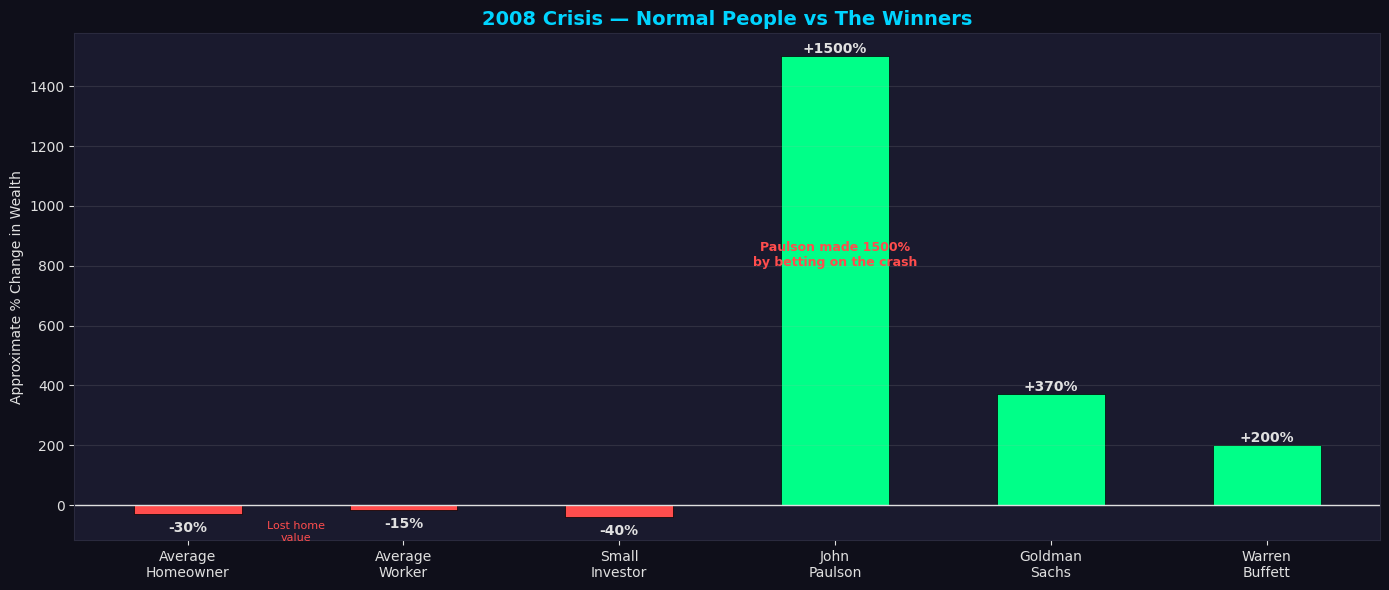

✅ Saved as crisis_2008_winners_vs_losers.png


In [28]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

categories = [
    'Average\nHomeowner',
    'Average\nWorker',
    'Small\nInvestor',
    'John\nPaulson',
    'Goldman\nSachs',
    'Warren\nBuffett',
]
outcomes = [-30, -15, -40, +1500, +370, +200]
colors   = [RED if x < 0 else GREEN for x in outcomes]

bars = ax.bar(categories, outcomes, color=colors,
              edgecolor='black', linewidth=0.5, width=0.5)

for bar, val in zip(bars, outcomes):
    label = f'+{val}%' if val > 0 else f'{val}%'
    ypos  = bar.get_height() + 10 if val > 0 else bar.get_height() - 60
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            label, ha='center', fontsize=10,
            fontweight='bold', color=TEXT)

ax.axhline(0, color=TEXT, linewidth=1)
ax.set_ylabel("Approximate % Change in Wealth", color=TEXT)
ax.set_title("2008 Crisis — Normal People vs The Winners",
             color='#00d4ff', fontsize=14, fontweight='bold')
ax.tick_params(colors=TEXT)

# Annotations
ax.text(3.0, 800,
        'Paulson made 1500%\nby betting on the crash',
        color=RED, fontsize=9, ha='center', fontweight='bold')
ax.text(0.5, -120,
        'Lost home\nvalue',
        color=RED, fontsize=8, ha='center')

for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a3e')
ax.grid(axis='y', alpha=0.15)

plt.tight_layout()
plt.savefig('crisis_2008_winners_vs_losers.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved as crisis_2008_winners_vs_losers.png")
